Shape ban đầu: (30229, 12)

Phân bố City sau extract:
city
HCM             11628
HN               9996
BD               1655
ĐN               1411
Đồng Nai          806
Hải Phòng         786
Khánh Hòa         730
Hà Nội.           461
HY                403
LA                328
BRVT              238
Bắc Ninh          165
Hồ Chí Minh.      150
Bình Thuận        126
Lâm Đồng          117
Name: count, dtype: int64

Phân bố District sau extract:
district
Gò Vấp          1373
Hà Đông         1277
Long Biên       1240
Bình Tân        1158
Thủ Đức         1142
Hoàng Mai       1018
Tân Phú         1012
Đống Đa          980
Quận 12          940
Bình Thạnh       851
Tân Bình         850
Nam Từ Liêm      771
Hai Bà Trưng     770
Thanh Xuân       766
Quận 9           713
Other            681
Nha Trang        672
Quận 7           644
Dĩ An            591
Biên Hòa         588
Name: count, dtype: int64
Drop balcony_direction vì missing rate: 82.65%


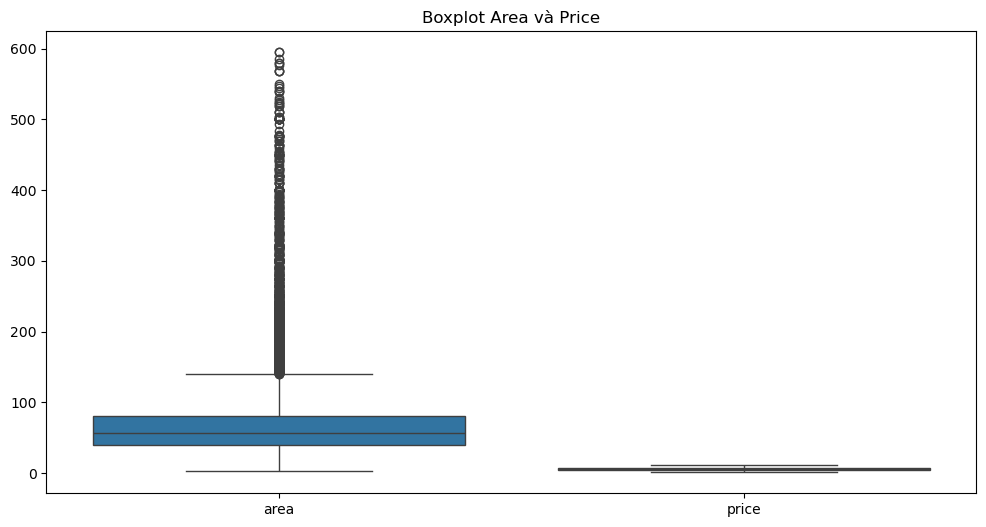

Sau loại outliers: 28593 dòng
NaN trong log_price trước clean: 0
NaN tổng: 0
Sau clean NaN cuối: 28593 dòng
Cat features: []
0:	learn: 0.2865002	test: 0.2887754	best: 0.2887754 (0)	total: 141ms	remaining: 16m 26s
200:	learn: 0.1681924	test: 0.1758271	best: 0.1758271 (200)	total: 1.33s	remaining: 45s
400:	learn: 0.1545752	test: 0.1633253	best: 0.1633253 (400)	total: 2.54s	remaining: 41.9s
600:	learn: 0.1481218	test: 0.1578732	best: 0.1578732 (600)	total: 3.78s	remaining: 40.2s
800:	learn: 0.1436769	test: 0.1541875	best: 0.1541875 (800)	total: 5.06s	remaining: 39.1s
1000:	learn: 0.1401433	test: 0.1514134	best: 0.1514134 (1000)	total: 6.31s	remaining: 37.8s
1200:	learn: 0.1374275	test: 0.1493085	best: 0.1493085 (1200)	total: 7.51s	remaining: 36.2s
1400:	learn: 0.1349980	test: 0.1476581	best: 0.1476581 (1400)	total: 8.72s	remaining: 34.8s
1600:	learn: 0.1327975	test: 0.1462316	best: 0.1462316 (1600)	total: 9.94s	remaining: 33.5s
1800:	learn: 0.1310034	test: 0.1450774	best: 0.1450774 (1800)

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ========================
# 1. ĐỌC DỮ LIỆU
# ========================
df = pd.read_csv('vietnam_housing_dataset - Copy.csv')  # thay đường dẫn nếu cần

print(f"Shape ban đầu: {df.shape}")

# Chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Chuyển đổi kiểu dữ liệu
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['area'] = pd.to_numeric(df['area'], errors='coerce')

df = df.dropna(subset=['price', 'area'])
df = df[(df['price'] > 0) & (df['area'] > 0)]

# ========================
# BƯỚC 1: TRÍCH XUẤT ĐẶC TRƯNG TỪ ADDRESS
# ========================
def extract_location(address):
    if pd.isna(address) or not isinstance(address, str):
        return 'Other', 'Other', 'Other'
    
    parts = [p.strip() for p in address.split(',')]
    
    if len(parts) < 2:
        return 'Other', 'Other', 'Other'
    
    city = parts[-1].title()
    
    district = 'Other'
    ward = 'Other'
    
    if len(parts) >= 2:
        candidate_district = parts[-2].title()
        if 'Quận' in candidate_district or 'Huyện' in candidate_district or 'Thị Xã' in candidate_district:
            district = candidate_district
        elif len(parts) >= 3:
            candidate_ward = parts[-3].title()
            if 'Phường' in candidate_ward or 'Xã' in candidate_ward:
                ward = candidate_ward
                district = parts[-2].title()
    
    city_map = {
        'Hồ Chí Minh': 'HCM', 'Tp. Hồ Chí Minh': 'HCM',
        'Hà Nội': 'HN',
        'Hưng Yên': 'HY', 'Bình Dương': 'BD', 'Đà Nẵng': 'ĐN',
        'Long An': 'LA', 'Đồng Nai': 'Đồng Nai', 'Bà Rịa Vũng Tàu': 'BRVT',
    }
    city = city_map.get(city, city)
    
    return city, district, ward

df['city'], df['district'], df['ward'] = zip(*df['address'].apply(extract_location))
df = df.drop('address', axis=1)

print("\nPhân bố City sau extract:")
print(df['city'].value_counts().head(15))

print("\nPhân bố District sau extract:")
print(df['district'].value_counts().head(20))

# ========================
# BƯỚC 2: XỬ LÝ MISSING VALUES
# ========================
numerical_cols = ['frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']

for col in numerical_cols:
    if col in df.columns:
        df[col] = df.groupby('district')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

categorical_cols = ['house_direction', 'balcony_direction', 'legal_status', 'furniture_state']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Drop balcony_direction nếu missing quá nhiều
if 'balcony_direction' in df.columns:
    missing_rate = (df['balcony_direction'] == 'Unknown').mean()
    if missing_rate > 0.7:
        print(f"Drop balcony_direction vì missing rate: {missing_rate:.2%}")
        df = df.drop('balcony_direction', axis=1)
        categorical_cols.remove('balcony_direction')

# ========================
# BƯỚC 3: XỬ LÝ OUTLIERS
# ========================
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['area', 'price']])
plt.title('Boxplot Area và Price')
plt.show()

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers(df, 'area')
df = remove_outliers(df, 'price')

print(f"Sau loại outliers: {df.shape[0]} dòng")

# ========================
# TẠO LOG_PRICE NGAY TẠI ĐÂY (trước clean NaN)
# ========================
df['log_price'] = np.log1p(df['price'])

# ========================
# BƯỚC 4: MÃ HÓA CATEGORICAL
# ========================
onehot_cols = ['legal_status', 'furniture_state']
if onehot_cols:
    onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    onehot_encoded = pd.DataFrame(onehot_encoder.fit_transform(df[onehot_cols]), 
                                  columns=onehot_encoder.get_feature_names_out(onehot_cols),
                                  index=df.index)
    df = pd.concat([df.drop(onehot_cols, axis=1), onehot_encoded], axis=1)

target_enc_cols = ['city', 'district', 'ward', 'house_direction']
target_enc_cols = [col for col in target_enc_cols if col in df.columns]

if target_enc_cols:
    target_encoder = TargetEncoder()
    df[target_enc_cols] = target_encoder.fit_transform(df[target_enc_cols], df['price'])

# ========================
# BƯỚC 5: CHUẨN HÓA DỮ LIỆU
# ========================
scaler_cols = ['area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
scaler_cols = [col for col in scaler_cols if col in df.columns]

if scaler_cols:
    scaler = StandardScaler()
    df[scaler_cols] = scaler.fit_transform(df[scaler_cols])

# ========================
# CLEAN FINAL TRƯỚC TRAIN (fix NaN)
# ========================
print("NaN trong log_price trước clean:", df['log_price'].isna().sum())
print("NaN tổng:", df.isna().sum().sum())

important_cols = ['log_price'] + scaler_cols + ['price']
df = df.dropna(subset=important_cols)

for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna('Unknown')

print(f"Sau clean NaN cuối: {df.shape[0]} dòng")

# ========================
# CHUẨN BỊ TRAIN/TEST
# ========================
X = df.drop(['price', 'log_price'], axis=1, errors='ignore')
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cat features: các cột object/category còn lại (nếu có)
cat_features = [col for col in X.columns if X[col].dtype.name in ['object', 'category']]

print(f"Cat features: {cat_features}")

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostRegressor(
    iterations=7000,
    learning_rate=0.012,
    depth=8,
    l2_leaf_reg=6,
    random_seed=42,
    loss_function='RMSE',
    eval_metric='MAE',
    early_stopping_rounds=180,
    verbose=200,
    use_best_model=True
)

model.fit(train_pool, eval_set=test_pool)

# ========================
# ĐÁNH GIÁ
# ========================
y_pred_log = model.predict(X_test)

print("\n=== Log Price Metrics ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_log):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.5f}")
print(f"R²: {r2_score(y_test, y_pred_log):.5f}")

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

print("\n=== Giá thật (tỷ VND) ===")
print(f"MAE: {mean_absolute_error(y_test_real, y_pred_real):,.2f} tỷ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_real, y_pred_real)):.2f} tỷ")
print(f"R²: {r2_score(y_test_real, y_pred_real):.4f}")

# Feature importance
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False).head(15)

print("\n=== Top 15 features quan trọng nhất ===")
print(fi.to_string(index=False))

In [2]:
# ĐÁNH GIÁ
# ========================
y_pred_log = model.predict(X_test)

print("\n=== Log Price Metrics ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_log):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.5f}")
print(f"R²: {r2_score(y_test, y_pred_log):.5f}")

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

print("\n=== Giá thật (tỷ VND) ===")
print(f"MAE: {mean_absolute_error(y_test_real, y_pred_real):,.2f} tỷ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_real, y_pred_real)):.2f} tỷ")
print(f"R²: {r2_score(y_test_real, y_pred_real):.4f}")


=== Log Price Metrics ===
MAE: 0.13529
RMSE: 0.18443
R²: 0.73785

=== Giá thật (tỷ VND) ===
MAE: 0.89 tỷ
RMSE: 1.22 tỷ
R²: 0.6952
